# Figure 1 K-M: Freely moving augmented reality, system and performance

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2026-01-27 13:23:32,081::INFO::settings.py::Setting loglevel to INFO
2026-01-27 13:23:32,082::INFO::settings.py::Setting stores to {}
2026-01-27 13:23:32,083::INFO::settings.py::Setting database.misc.schema_prefix to 
2026-01-27 13:23:32,085::INFO::settings.py::Setting database.misc.create_tables to True
2026-01-27 13:23:32,086::INFO::settings.py::Setting enable_python_native_blobs to True
2026-01-27 13:23:32,087::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2026-01-27 13:23:32,088::INFO::settings.py::Setting database.user to celia
2026-01-27 13:23:32,090::INFO::settings.py::Setting database.password to celia_mathislab
2026-01-27 13:23:32,263::INFO::connection.py::Connected celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2026-01-27 13:23:32,371::INFO::table.py::could not log event in table ~log
2026-01-27 13:23:32,798::INFO::table.py::could not log event in table ~log
2026-01-27 13:23:32,798::INFO::table.py::could not log event in table ~log
2026-01-27 13:23:33,300::INFO::table.py::could not log event in table ~log
2026-01-27 13:23:33,300::INFO::table.py::could not log event in table ~log
2026-01-27 13:23:33,445::INFO::table.py::could not log event in table ~log
2026-01-27 13:23:33,445::INFO::table.py::could not log event in table ~log
2026-01-27 13:23:33,779::INFO::table.py::could not log event in table ~log
2026-01-27 13:23:33,779::INFO::table.py::could not log event in table ~log
2026-01-27 13:23:34,095::INFO::table.py::could not log event in table ~log
2026-01-27 13:23:34,095::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema.session_metrics import SessionMetrics
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.schema import dlc
from base_schemas.schemas import exp
from vr4mice.analysis.utils import get_data_from_list, get_training_stage_per_mouse
from vr4mice.analysis.stats import tukey_results_to_matrix, plot_training_stats_heatmap

import statsmodels.api as sm
from statsmodels.formula.api import ols

style()

2026-01-27 13:23:34,278::INFO::table.py::could not log event in table ~log
2026-01-27 13:23:34,278::INFO::table.py::could not log event in table ~log


In [ ]:
save_fig_path = "notebooks/Paper_figures/Figure_output/"

# Fetch data and transform into dataframe

In [12]:
# could maybe move this out into a function since it because a bit of a long fetch call
data = []
for stage in ["ar_detection_no_velthr", "ar_detection_velthr", "ar_discrim"]:
    training = (vr4mice.Groups() * vr4mice.Labels() & (vr4mice.Dataset() & f'session_label = "{stage}"')).fetch("dataset", as_dict=True)
    for d in training:
        
        dataset_name = d["dataset"]
        print(dataset_name)
        df = pd.DataFrame((SessionMetrics() & f'dataset = "{dataset_name}"').fetch(as_dict = True))
        split_d = dataset_name.split("_")
        df["mouse_name"] = split_d[0]
        df["date"] = split_d[1]
        df["attempt"] = split_d[2]
        df["training_stage"] = stage
        df["lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]
        data.append(df)
big_df = pd.concat(data)  
 
big_df["session_increment"] = (
    big_df.groupby("mouse_name")["dataset"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

# remove failed session need to correct in datajoint - there was a second attempt run I need to correct its label
big_df = big_df [big_df.dataset != "Lemming_2024-08-09_1"].copy()
combined_training_df = []
for mouse_name in big_df.mouse_name.unique():
   tmp_df = get_training_stage_per_mouse(big_df, mouse_name)
   combined_training_df.append(tmp_df)
session_df = pd.concat(combined_training_df)

31726_2025-02-06_1
31726_2025-02-07_1
31726_2025-02-10_1
31726_2025-02-11_1
31726_2025-02-12_1
31726_2025-02-13_1
31728_2025-02-06_1
31728_2025-02-07_1
31728_2025-02-10_1
31728_2025-02-11_1
31728_2025-02-12_1
31728_2025-02-13_1
J729_2024-11-09_1
J729_2024-11-10_1
J729_2024-11-11_1
J729_2024-11-12_1
J729_2024-11-13_1
J729_2024-11-14_1
J729_2024-11-15_1
J729_2024-11-16_1
J729_2024-11-17_1
J731_2024-11-09_1
J731_2024-11-10_1
J731_2024-11-11_1
J731_2024-11-12_1
J731_2024-11-13_1
J731_2024-11-14_1
J731_2024-11-15_1
J731_2024-11-16_1
J731_2024-11-17_1
Jacana_2024-07-28_1
Jacana_2024-07-29_2
Jacana_2024-07-30_1
Jacana_2024-07-31_1
Jacana_2024-08-01_1
Jacana_2024-08-02_1
Jacana_2024-08-05_2
Jacana_2024-08-06_1
Jacana_2024-08-07_1
Kiwi_2024-07-26_1
Kiwi_2024-07-27_1
Kiwi_2024-07-28_1
Kiwi_2024-07-29_1
Kiwi_2024-07-30_1
Kiwi_2024-07-31_1
Kiwi_2024-08-01_1
Lemming_2024-07-27_1
Lemming_2024-07-28_1
Lemming_2024-07-29_2
Lemming_2024-07-30_1
Lemming_2024-07-31_1
Lemming_2024-08-01_1
Nightingale_2024

# Mean Training plots

2025-07-10 10:51:09,842::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:09,842::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:09,852::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:09,852::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Anova
                   df    sum_sq   mean_sq         F    PR(>F)
num_train_stage   1.0  0.147007  0.147007  8.130146  0.006192
Residual         53.0  0.958333  0.018082       NaN       NaN
TuckeyHSD
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1    0.147 0.0749 -0.0088  0.3027  False
     0      2   0.1703 0.0246  0.0145  0.3261   True
     0      3   0.0102    1.0 -0.1456   0.166  False
     0      4   0.1733  0.095 -0.0175  0.3641  False
     0      5   0.2288 0.0009   0.073  0.3846   True
     1      2   0.0233 0.9977 -0.1325  0.1791  False
     1      3  -0.1368 0.1157 -0.2926   0.019  False
     1      4   0.0263 0.9984 -0.1645  0.2171  False
     1      5   0.0818 0.6295  -0.074  0.2376  False
     2      3  -0.1601 0.0407 -0.3159 -0.0043   True
     2      4    0.003    1.0 -0.1878  0.1938  False
     2      5   0.0585 0.8734 -0.0973  0.2143  False
   

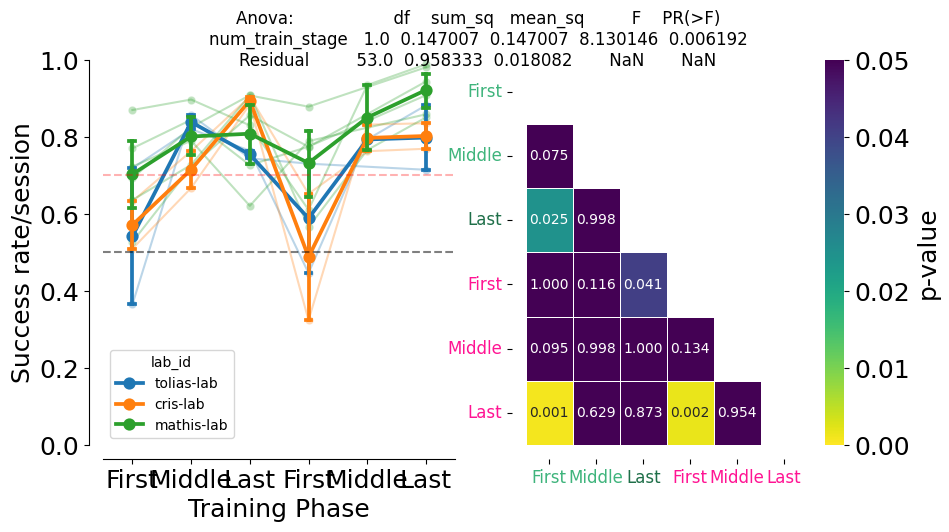

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(ax[0], data=session_df, y="session_reward", ylabel="Success rate/session", ylim=(0,1), hue="lab_id")

anova_rewarded = ols('session_reward ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print("Anova")
print(table)
print("TuckeyHSD")
results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_reward, session_df.num_train_stage, alpha=0.05)
print(results.summary())
fig.suptitle(f"Anova:{table}")

sns.despine(offset=10)

# Plot heatmap
plot_training_stats_heatmap(ax [1], results)
plt.savefig(save_fig_path + "figure1_training_success_rate.svg", transparent=True)

In [8]:
results.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
0,1,0.147,0.0749,-0.0088,0.3027,False
0,2,0.1703,0.0246,0.0145,0.3261,True
0,3,0.0102,1.0,-0.1456,0.166,False
0,4,0.1733,0.095,-0.0175,0.3641,False
0,5,0.2288,0.0009,0.073,0.3846,True
1,2,0.0233,0.9977,-0.1325,0.1791,False
1,3,-0.1368,0.1157,-0.2926,0.019,False
1,4,0.0263,0.9984,-0.1645,0.2171,False
1,5,0.0818,0.6295,-0.074,0.2376,False
2,3,-0.1601,0.0407,-0.3159,-0.0043,True


2025-07-10 10:51:11,200::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:11,200::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:11,211::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:11,211::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Anova
                   df      sum_sq     mean_sq         F    PR(>F)
num_train_stage   1.0  138.855866  138.855866  8.328483  0.005634
Residual         53.0  883.637602   16.672408       NaN       NaN
TuckeyHSD


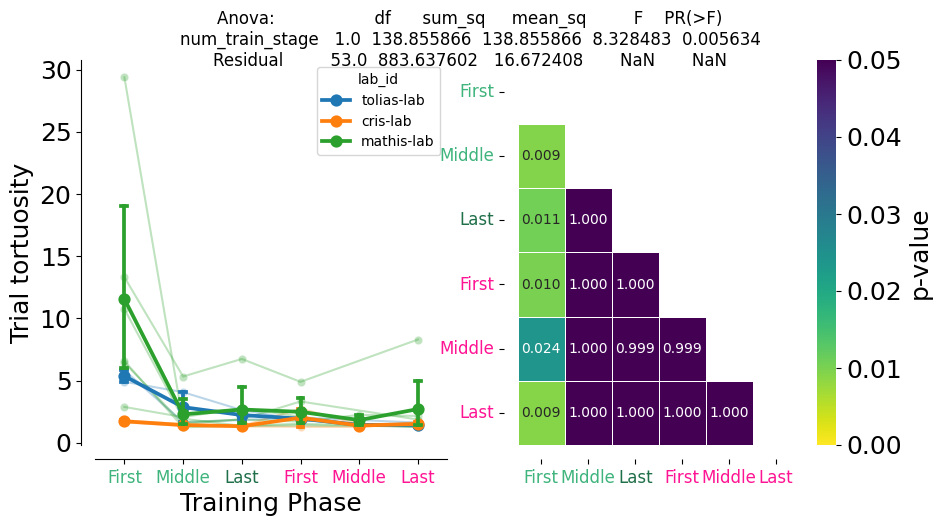

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(ax[0], data=session_df, y="session_tortuosity", ylabel="Trial tortuosity", hue="lab_id")

anova_rewarded = ols('session_tortuosity ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print("Anova")
print(table)
print("TuckeyHSD")
results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_tortuosity, session_df.num_train_stage, alpha=0.05)
results.summary()
plot_training_stats_heatmap(ax [1], results)
fig.suptitle(f"Anova:{table}")

plt.savefig(save_fig_path + "figure1_training_tortuosity.svg", transparent=True)

2025-07-10 10:51:12,501::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:12,501::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:12,524::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:12,524::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Anova
                   df       sum_sq     mean_sq          F    PR(>F)
num_train_stage   1.0   773.058815  773.058815  11.271117  0.001463
Residual         53.0  3635.142448   68.587593        NaN       NaN
TuckeyHSD


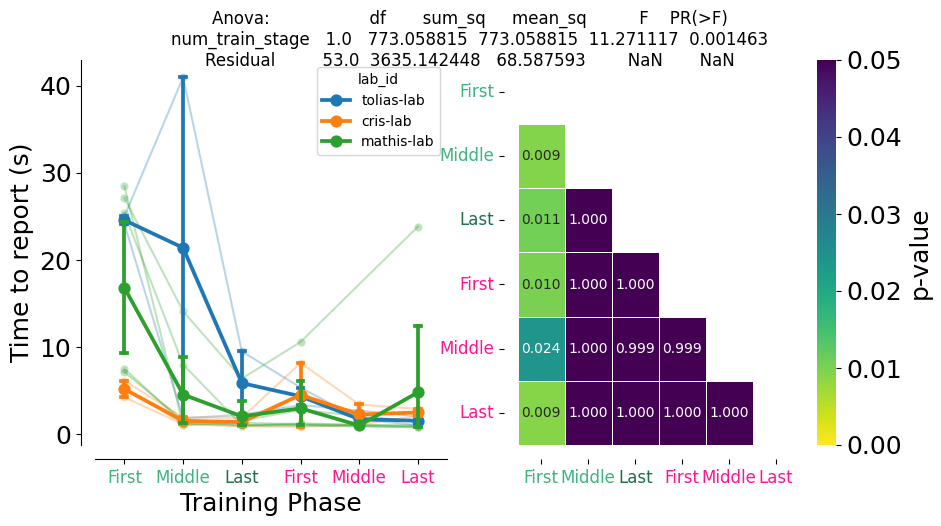

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(ax[0], data=session_df, y="session_trial_duration", ylabel="Time to report (s)", hue="lab_id")

anova_rewarded = ols('session_trial_duration ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print("Anova")
print(table)
print("TuckeyHSD")
results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_tortuosity, session_df.num_train_stage, alpha=0.05)
results.summary()
plot_training_stats_heatmap(ax [1], results)
fig.suptitle(f"Anova:{table}")

plt.savefig(save_fig_path + "figure1_training_trial_duration.svg", transparent=True)

2026-01-27 13:28:40,473::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 13:28:40,473::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 13:28:40,484::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-27 13:28:40,484::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


                   df    sum_sq   mean_sq         F    PR(>F)
num_train_stage   1.0  0.015363  0.015363  0.319889  0.574061
Residual         53.0  2.545380  0.048026       NaN       NaN
One-sample t-tests vs 0 (bias)
   num_train_stage   n  mean_bias    t_stat  df   p_value
0                0  10   0.024020  0.315024   9  0.759925
1                1  10   0.099960  1.243030   9  0.245264
2                2  10   0.072631  0.913433   9  0.384832
3                3  10   0.215386  3.028606   9  0.014279
4                4   5   0.156937  5.195691   4  0.006535
5                5  10   0.042537  0.990603   9  0.347763


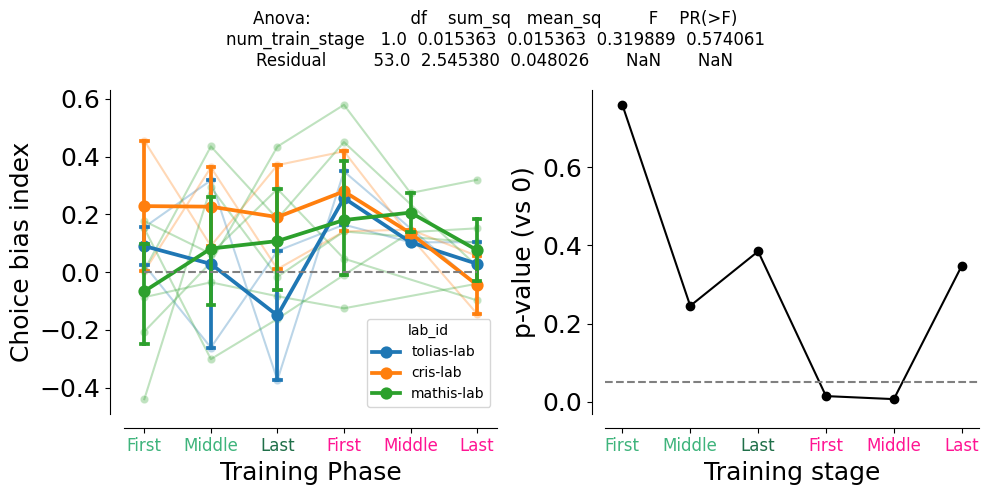

In [ ]:
session_df["session_bias_index"] = 2 * session_df["session_bias"] - 1 

fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(
    ax[0],
    data=session_df,
    y="session_bias_index",
    ylabel="Choice bias index",
    ylim=(1, -1),
    hue="lab_id",
)

anova_rewarded = ols('session_bias_index ~ num_train_stage', data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print(table)

ax[0].hlines(0.0, xmin=0, xmax=session_df.num_train_stage.max(), color="grey", linestyle="--")

# One-sample t-test of bias against 0 (null) per training stage
stage_tests = []
for stage in sorted(session_df.num_train_stage.unique()):
    vals = session_df.loc[session_df.num_train_stage == stage, "session_bias_index"]
    t_stat, p_val = stats.ttest_1samp(vals, 0)
    stage_tests.append({
        "num_train_stage": stage,
        "n": len(vals),
        "mean_bias": vals.mean(),
        "t_stat": t_stat,
        "df": max(len(vals) - 1, 0),
        "p_value": p_val,
    })
stage_tests_df = pd.DataFrame(stage_tests)
print("One-sample t-tests vs 0 (bias)")
print(stage_tests_df)

# Plot p-values only (no bar/box)
ax[1].plot(stage_tests_df["num_train_stage"], stage_tests_df["p_value"], 
           marker="o", linestyle="-", color="k")
ax[1].axhline(0.05, color="grey", linestyle="--")
ax[1].set_xlabel("Training stage")
ax[1].set_ylabel("p-value (vs 0)")

# Define tick positions and labels
stage_positions = np.arange(6)
stage_labels = ["First", "Middle", "Last", "First", "Middle", "Last"]
stage_colors = [
    "#3FB47C",
    "#3FB47C",
    "#1F6F49",
    "#FF1493",
    "#FF1493",
    "#FF1493",
]
ax[1].set_xticks(stage_positions)
ax[1].set_xticklabels(stage_labels, rotation=0, fontsize=12)
# Color the x-tick labels
for j, label in enumerate(ax[1].get_xticklabels()):
    label.set_color(stage_colors[j])
    
fig.suptitle(f"Anova:{table}")
plt.tight_layout()
plt.savefig(save_fig_path + "figure1_training_bias.svg", transparent=True)

2025-07-10 10:51:14,870::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:14,870::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:14,893::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:14,893::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


                   df         sum_sq       mean_sq          F    PR(>F)
num_train_stage   1.0   88504.064246  88504.064246  22.752666  0.000015
Residual         53.0  206161.135754   3889.832750        NaN       NaN
Anova


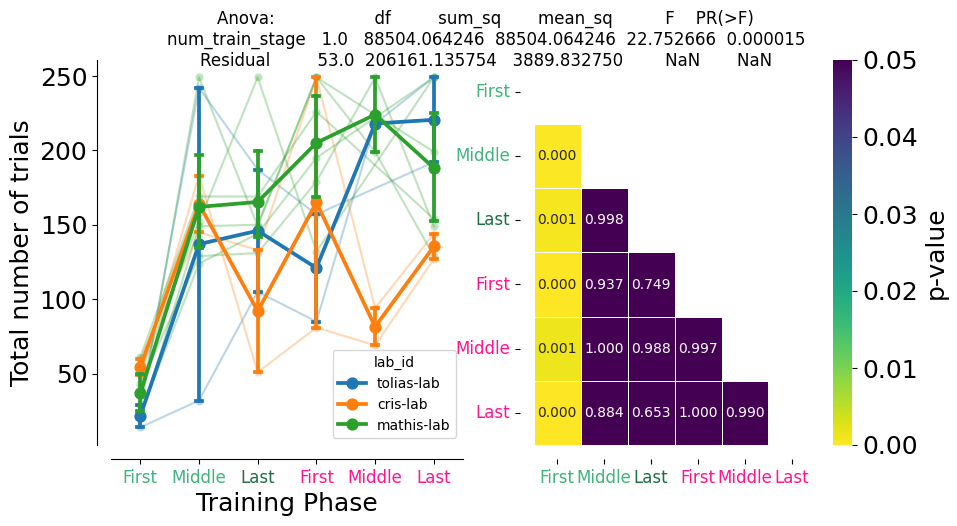

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(ax[0], data=session_df, y="session_max_trial_number", ylabel="Total number of trials", hue="lab_id")

anova_rewarded = ols('session_max_trial_number ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print(table)
print("Anova")
results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_max_trial_number, session_df.num_train_stage, alpha=0.05)
results.summary()
plot_training_stats_heatmap(ax [1], results)
fig.suptitle(f"Anova:{table}")

plt.savefig(save_fig_path + "figure1_training_max_trial_number.svg", transparent=True)

2025-07-10 10:51:16,082::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:16,082::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2025-07-10 10:51:16,094::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:16,094::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


                   df    sum_sq   mean_sq          F    PR(>F)
num_train_stage   1.0  1.238463  1.238463  29.529584  0.000001
Residual         53.0  2.222806  0.041940        NaN       NaN
Anova


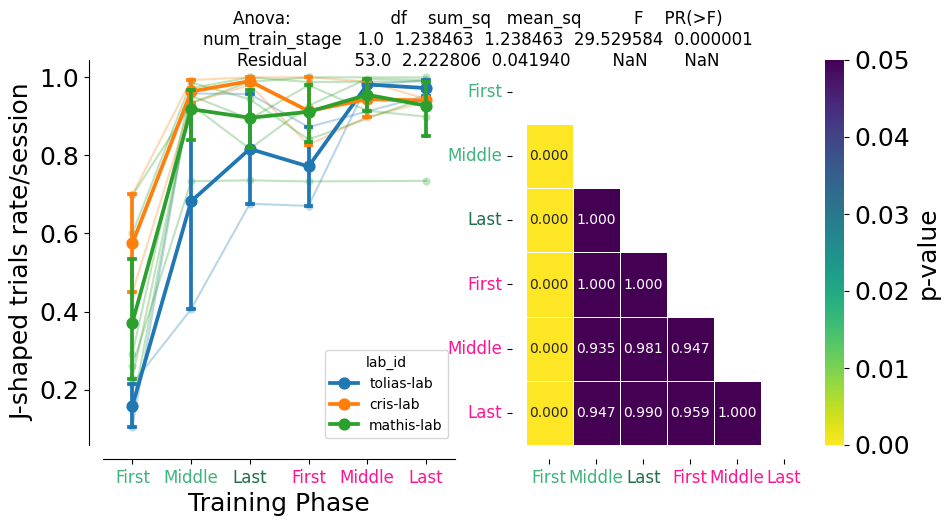

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(ax[0], data=session_df, y="session_jshaped", ylabel="J-shaped trials rate/session", hue="lab_id")
anova_rewarded = ols('session_jshaped ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print(table)
print("Anova")

results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_jshaped, session_df.num_train_stage, alpha=0.05)
results.summary()
plot_training_stats_heatmap(ax [1], results)
fig.suptitle(f"Anova:{table}")

plt.savefig(save_fig_path + "figure1_training_jshaped.svg", transparent=True)


# Just checking the strange looking mouse

Text(0.5, 1.0, 'Nightingale')

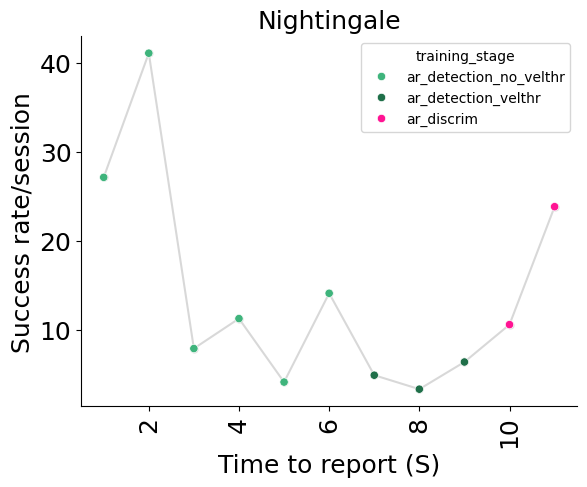

In [14]:
Nightingale  =big_df [big_df.mouse_name == "Nightingale"]
sns.lineplot(data = Nightingale, x="session_increment", y="session_trial_duration", units="mouse_name", estimator=None, marker="o", color="grey", zorder=0, alpha=.3)
sns.scatterplot(data = Nightingale, x="session_increment", y="session_trial_duration", hue="training_stage", palette=["#3FB47C",  "#1F6F49", "#FF1493"], zorder=10)
plt.xticks(rotation = 90)
plt.xlabel("Time to report (S)")
plt.ylabel("Success rate/session")
plt.title(f"{Nightingale.mouse_name.iloc[0]}")
#plt.ylim(0,1)

# Plotting by lab

In [15]:
session_df["lab_id"].unique()

array(['tolias-lab', 'cris-lab', 'mathis-lab'], dtype=object)

2025-07-10 10:51:17,611::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:17,611::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:17,622::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:17,622::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


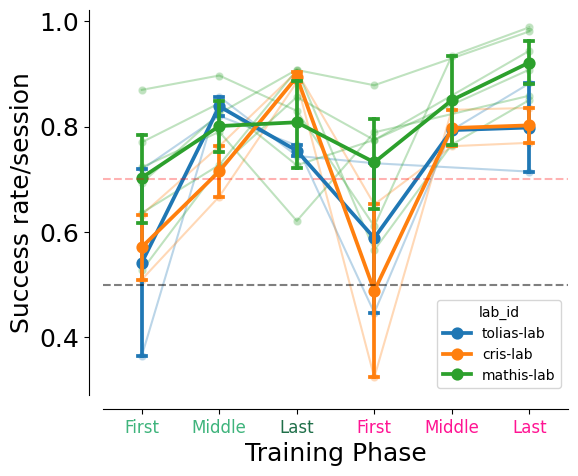

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
plotting.plot_training_phases(ax, data=session_df, y="session_reward", ylabel="Success rate/session",hue="lab_id")

plt.savefig(save_fig_path + "figure1_training_by_labs_session_reward.svg", transparent=True)

2025-07-10 10:51:18,281::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2025-07-10 10:51:18,281::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:18,290::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:18,290::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='Training Phase', ylabel='Trial tortuosity'>

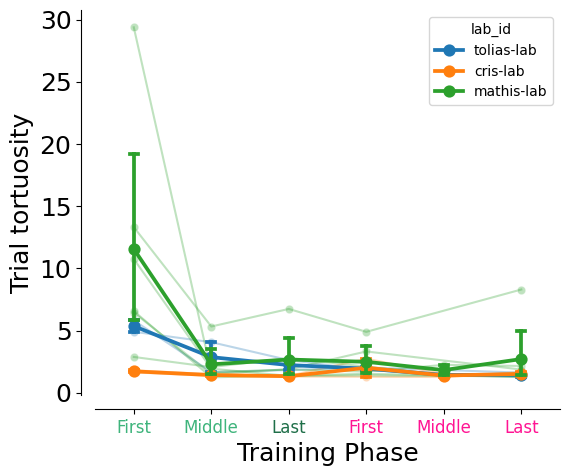

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
plotting.plot_training_phases(ax, data=session_df, y="session_tortuosity", ylabel="Trial tortuosity",hue="lab_id")

2025-07-10 10:51:19,033::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:19,033::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:19,043::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:19,043::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='Training Phase', ylabel='Trial number'>

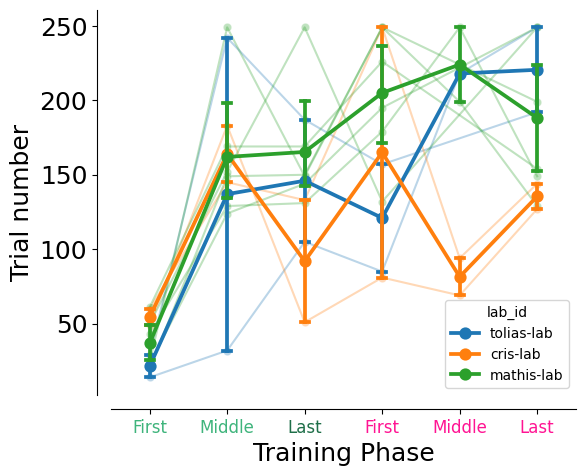

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
plotting.plot_training_phases(ax, data=session_df, y="session_max_trial_number", ylabel="Trial number",hue="lab_id")

2025-07-10 10:51:19,724::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:19,724::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:19,739::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:19,739::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='Training Phase', ylabel='Time to report (s)'>

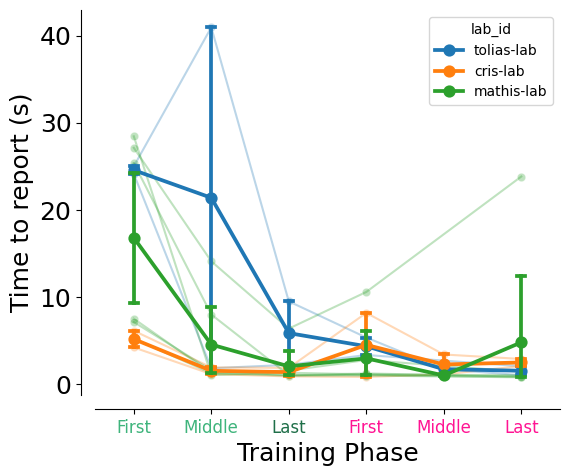

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
plotting.plot_training_phases(ax, data=session_df, y="session_trial_duration", ylabel="Time to report (s)",hue="lab_id")


2025-07-10 10:51:20,379::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:20,379::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:20,396::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:20,396::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 10:51:20,790::INFO::category.py::Using categorical un

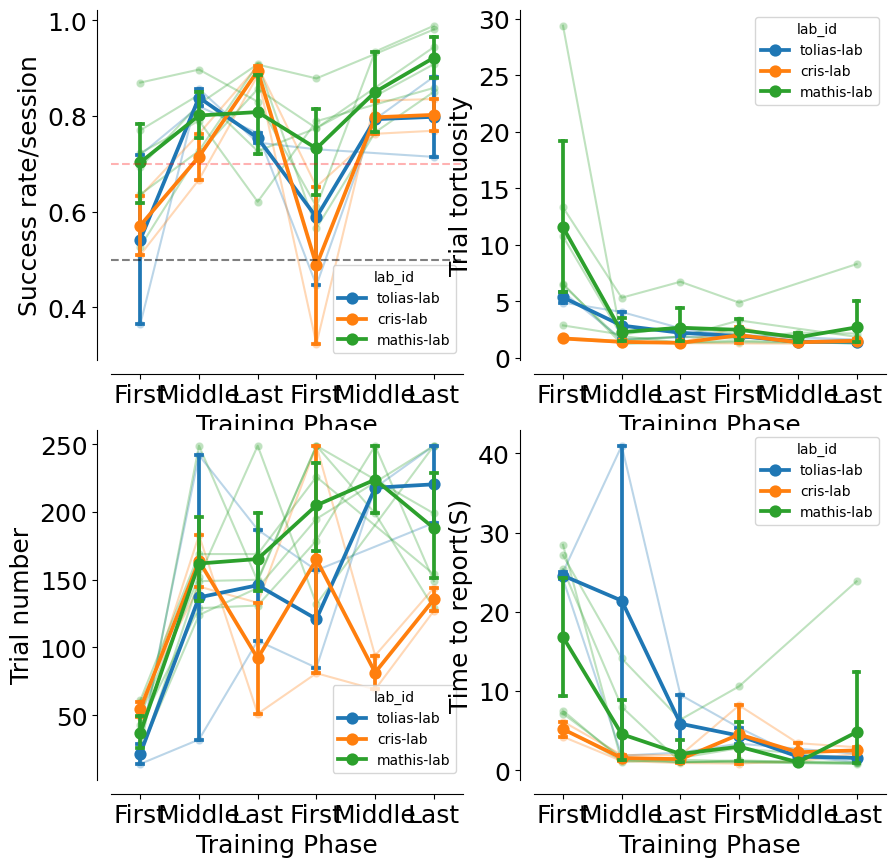

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(10,10))
plotting.plot_training_phases(ax[0,0], data=session_df, y="session_reward", ylabel="Success rate/session",hue="lab_id")
plotting.plot_training_phases(ax[0,1], data=session_df, y="session_tortuosity", ylabel="Trial tortuosity",hue="lab_id")
plotting.plot_training_phases(ax[1,0], data=session_df, y="session_max_trial_number", ylabel="Trial number",hue="lab_id")
plotting.plot_training_phases(ax[1,1], data=session_df, y="session_trial_duration", ylabel="Time to report(S)",hue="lab_id")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure1_training_by_labs.svg", transparent=True)

In [21]:
training_days = big_df.groupby(["mouse_name"], as_index=False)["dataset"].nunique()
training_days["trials"] = big_df.groupby(["mouse_name"], as_index=False)["session_max_trial_number"].sum()["session_max_trial_number"]

In [22]:
training_days.mean(), training_days.sem()

(dataset      13.4
 trials     1644.0
 dtype: float64,
 dataset      1.758787
 trials     143.573984
 dtype: float64)

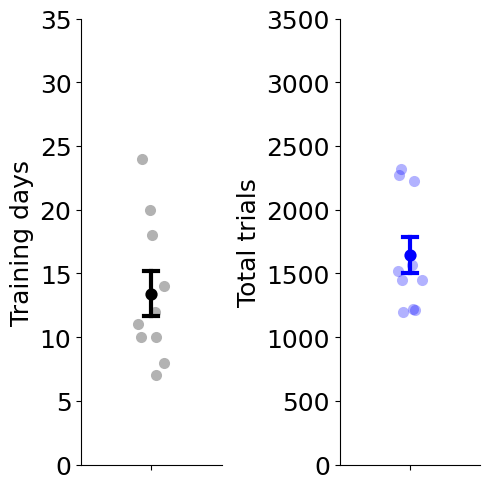

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(5,5))
sns.stripplot(
    data=training_days,
    y="dataset",
    color="black",
    jitter=True,
    size=8,
    alpha=0.3,
    zorder=0,
    ax=ax[0]
)

sns.pointplot(
    data=training_days,
    y="dataset",
    join=False,
    color="black",
    markers="o",
    errorbar="se",
    capsize=0.1,
    errwidth=3,
    zorder=2,
    ax=ax[0]
)

 
ax[0].set_ylim(0,35)
ax[0].set_ylabel("Training days")

sns.stripplot(
    data=training_days,
    y="trials",
    color="blue",
    jitter=True,
    size=8,
    alpha=0.3,
    zorder=0,
    ax=ax[1]
)
sns.pointplot(
    data=training_days,
    y="trials",
    join=False,
    color="blue",
    markers="o",
    errorbar="se",
    capsize=0.1,
    errwidth=3,
    zorder=2,
    ax=ax[1]
)

ax[1].set_ylim(0,3500)
ax[1].set_ylabel("Total trials")
plt.tight_layout()
plt.savefig(save_fig_path + "figure1_training_days_and_trials.svg", transparent=True)